In [1]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [73]:
def saturation(value):
  if value > 255:
    value = 255
  elif value < 0:
    value = 0
  return value

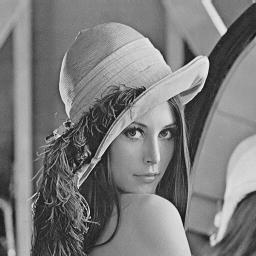

In [74]:
img = cv2.imread('/content/gdrive/My Drive/ColabIP26/Images/lena256.jpg')
gimg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2_imshow(gimg)

In [75]:
gOut = np.zeros((gimg.shape[0], gimg.shape[1]), dtype=np.ubyte)

In [76]:
gOut = np.zeros((gimg.shape[0], gimg.shape[1]), dtype=np.ubyte)

planeNumber = 1
planeValue = 128 #최상위 비트

for i in range(planeNumber-1):
  planeValue = planeValue * 2

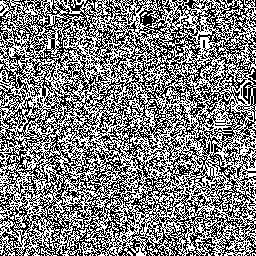

In [77]:
for h in range(gimg.shape[0]):
  for w in range(gimg.shape[1]):
    if(gimg[h,w] % 2 == 0):
      gOut[h,w] = 0
    else:
      gOut[h,w] = 255

cv2_imshow(gOut)

#최하위 비트플레인
#최하위는 그냥 없애버려도 무방함. but 무언가를 해볼거임

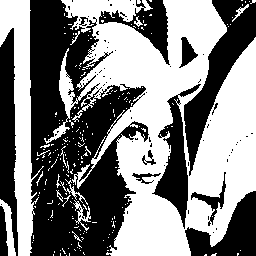

In [78]:
for h in range(gimg.shape[0]):
  for w in range(gimg.shape[1]):
    imVal = np.int32((gimg[h,w]) / planeValue); #이거 추가됨
    if(imVal % 2 == 0):
      gOut[h,w] = 0
    else:
      gOut[h,w] = 255

cv2_imshow(gOut)

# 최상위 비트플레인

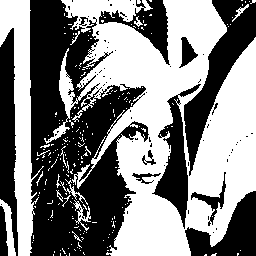

In [79]:
for h in range(gimg.shape[0]):
  for w in range(gimg.shape[1]):
    imVal = np.int32((gimg[h,w]) / planeValue);
    if(imVal % 2 == 0):
      gOut[h,w] = 0
    else:
      gOut[h,w] = 255

cv2_imshow(gOut)

# 7번째 비트플레인

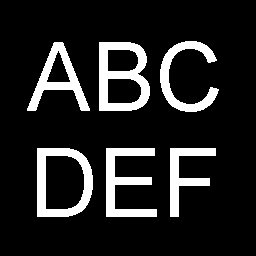

In [80]:
img = cv2.imread('/content/gdrive/My Drive/ColabIP26/Images/abcdef.bmp')
gimg2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2_imshow(gimg2)

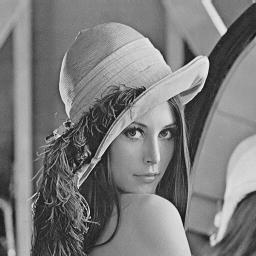

In [81]:
gWaterMarker = gimg.copy()
cv2_imshow(gWaterMarker)

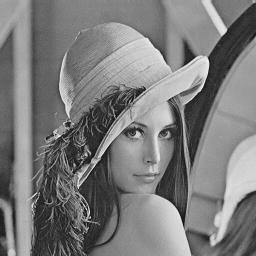

In [82]:
for h in range(gimg.shape[0]):
  for w in range(gimg.shape[1]):
    if(gimg2[h,w] > 128):
      if(gimg[h,w] % 2 == 0):
        gWaterMarker[h,w] += 1 #0일때는 1을 더해줌
      else:
        if(gimg[h,w] % 2 == 1):
          gWaterMarker[h,w] -= 1 #서명한거에서 까만 부분은 1에서 0으로 바꿔줌

cv2_imshow(gWaterMarker)

#최하위 비트에다가 워터마크 집어넣었음.

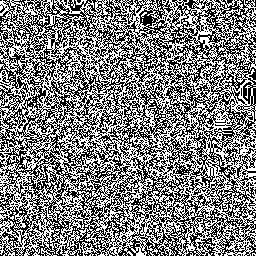

In [83]:
for h in range(gimg.shape[0]):
  for w in range(gimg.shape[1]):
    imVal = np.int32(gWaterMarker[h,w]);
    if(imVal % 2 == 0):
      gOut[h,w] = 0
    else:
      gOut[h,w] = 255

cv2_imshow(gOut)

#실패 안됨.